# KNU 2026 ML Final Assignment — v2 (p2)
## Improvements over v1:
1. **FFT + spectral band energy** — dominant frequency, low/mid/high band power
2. **Peak detection + cadence** — peak count, mean peak height, mean peak interval
3. **Direction-corrected posture** — rotate axes using phone direction → true vertical
4. **Dual context windows** — short (±1s) for amplitude, long (±4s) for frequency
5. **Device normalization** — per-device z-score on raw sensor values
6. **Temporal post-processing** — majority vote smoothing on final predictions


In [1]:
# Install required libraries
!pip install lightgbm catboost scikit-learn pandas numpy scipy -q



[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.signal import find_peaks, welch
from scipy.fft import rfft, rfftfreq
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GroupKFold
from sklearn.metrics import balanced_accuracy_score

import lightgbm as lgb
import catboost as cb

import os


In [3]:
# ── Configuration ──────────────────────────────────────────
DATA_DIR = '/Users/dayana/git repo/machine-learning-class/lab6/knu-2026-machine-learning-final-assignment'
SEED = 42
N_FOLDS = 5          # GroupKFold by pid (LOSO-style)
WINDOW_SEC = 1       # 1-second base window for feature extraction
CONTEXT_SEC = 2      # ±2 second context window for richer features

LGBM_PARAMS = {
    'objective': 'multiclass',
    'num_class': 9,
    'metric': 'multi_logloss',
    'learning_rate': 0.05,
    'num_leaves': 127,
    'max_depth': -1,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'lambda_l1': 0.1,
    'lambda_l2': 0.1,
    'verbose': -1,
    'n_jobs': -1,
    'seed': SEED,
}

CAT_PARAMS = {
    'iterations': 2000,
    'learning_rate': 0.05,
    'depth': 8,
    'l2_leaf_reg': 3,
    'loss_function': 'MultiClass',
    'eval_metric': 'TotalF1:average=Macro',
    'early_stopping_rounds': 150,
    'random_seed': SEED,
    'verbose': 0,
}

print("Config loaded.")


Config loaded.


In [4]:
# ── Load Raw Data ───────────────────────────────────────────
print("Loading sensor files (this may take ~1-2 minutes)...")

train_accel = pd.read_csv(os.path.join(DATA_DIR, 'train-accel.csv'))
train_gyro  = pd.read_csv(os.path.join(DATA_DIR, 'train-gyro.csv'))
train_label = pd.read_csv(os.path.join(DATA_DIR, 'train-label.csv'))

test_accel  = pd.read_csv(os.path.join(DATA_DIR, 'test-accel.csv'))
test_gyro   = pd.read_csv(os.path.join(DATA_DIR, 'test-gyro.csv'))
test_label  = pd.read_csv(os.path.join(DATA_DIR, 'test-label.csv'))

print(f"train_accel : {train_accel.shape}")
print(f"train_gyro  : {train_gyro.shape}")
print(f"train_label : {train_label.shape}")
print(f"test_accel  : {test_accel.shape}")
print(f"test_gyro   : {test_gyro.shape}")
print(f"test_label  : {test_label.shape}")


Loading sensor files (this may take ~1-2 minutes)...
train_accel : (2428374, 7)
train_gyro  : (2433673, 7)
train_label : (38015, 4)
test_accel  : (2528310, 7)
test_gyro   : (2541831, 7)
test_label  : (39473, 4)


In [5]:
# ── Improvement 1: Device Normalization ─────────────────────
# Apple vs Samsung have different sensor scales/offsets.
# Z-score normalize x, y, z per device within each split.
# We fit on train device stats and apply to both train and test.

def normalize_by_device(df_train, df_test, axes=['x', 'y', 'z']):
    """Z-score normalize sensor axes per device using train statistics."""
    df_train = df_train.copy()
    df_test  = df_test.copy()
    for device in df_train['device'].unique():
        tr_mask = df_train['device'] == device
        te_mask = df_test['device'] == device
        for ax in axes:
            mu  = df_train.loc[tr_mask, ax].mean()
            sig = df_train.loc[tr_mask, ax].std() + 1e-8
            df_train.loc[tr_mask, ax] = (df_train.loc[tr_mask, ax] - mu) / sig
            df_test.loc[te_mask,  ax] = (df_test.loc[te_mask,  ax] - mu) / sig
    return df_train, df_test

print("Normalizing accel by device...")
train_accel, test_accel = normalize_by_device(train_accel, test_accel)

print("Normalizing gyro by device...")
train_gyro, test_gyro = normalize_by_device(train_gyro, test_gyro)

print("Device normalization done.")
print(f"  Devices in train_accel: {train_accel['device'].unique()}")
print(f"  Devices in test_accel : {test_accel['device'].unique()}")


Normalizing accel by device...
Normalizing gyro by device...
Device normalization done.
  Devices in train_accel: <StringArray>
['samsung', 'Apple']
Length: 2, dtype: str
  Devices in test_accel : <StringArray>
['unknown', 'samsung', 'Apple']
Length: 3, dtype: str


In [6]:
# ── Improvement 2: Direction-Corrected Axes ─────────────────
# Phone direction encodes how the phone is oriented in the running belt.
# direction 1: screen out, top → right   (portrait, flipped horizontally)
# direction 2: screen out, top → left    (portrait, normal)
# direction 3: screen in,  top → right   (reverse portrait, flipped)
# direction 4: screen in,  top → left    (reverse portrait)
#
# Goal: produce a "body frame" signal where:
#   - vertical_axis ≈ the axis pointing up/down relative to body
#   - forward_axis  ≈ forward/backward relative to body
#   - lateral_axis  ≈ left/right relative to body
#
# Mapping based on direction:
#   dir 1: x_body =  y, y_body = -x, z_body =  z  (screen out, rotated 90° CW)
#   dir 2: x_body = -y, y_body =  x, z_body =  z  (screen out, rotated 90° CCW)
#   dir 3: x_body =  y, y_body = -x, z_body = -z  (screen in, rotated 90° CW)
#   dir 4: x_body = -y, y_body =  x, z_body = -z  (screen in, rotated 90° CCW)
#
# The key insight: z_body sign-flips for screen-in vs screen-out (dirs 3,4)
# and x/y swap depending on top orientation (left vs right)

def apply_direction_correction(df):
    """
    Rotate x, y, z into a canonical body frame based on phone direction.
    Adds columns: xb, yb, zb (body-frame axes).
    """
    df = df.copy()
    df['xb'] = df['x'].copy()
    df['yb'] = df['y'].copy()
    df['zb'] = df['z'].copy()

    for d, (sx, sy, sz) in {
        1: ( 'y', '-x',  'z'),
        2: ('-y',  'x',  'z'),
        3: ( 'y', '-x', '-z'),
        4: ('-y',  'x', '-z'),
    }.items():
        mask = df['direction'] == d
        df.loc[mask, 'xb'] = (df.loc[mask, 'x'] if sx == 'x'
                               else -df.loc[mask, 'x'] if sx == '-x'
                               else  df.loc[mask, 'y'] if sx == 'y'
                               else -df.loc[mask, 'y'])
        df.loc[mask, 'yb'] = (df.loc[mask, 'x'] if sy == 'x'
                               else -df.loc[mask, 'x'] if sy == '-x'
                               else  df.loc[mask, 'y'] if sy == 'y'
                               else -df.loc[mask, 'y'])
        df.loc[mask, 'zb'] = (df.loc[mask, 'z'] if sz == 'z'
                               else -df.loc[mask, 'z'])

    # Body-frame magnitude (should equal original magnitude)
    df['magb'] = np.sqrt(df['xb']**2 + df['yb']**2 + df['zb']**2)
    return df

print("Applying direction correction to accel...")
train_accel = apply_direction_correction(train_accel)
test_accel  = apply_direction_correction(test_accel)

print("Applying direction correction to gyro...")
train_gyro  = apply_direction_correction(train_gyro)
test_gyro   = apply_direction_correction(test_gyro)

print("Direction correction done.")
print("Sample accel after correction:")
print(train_accel[['direction','x','y','z','xb','yb','zb','magb']].head(4))


Applying direction correction to accel...
Applying direction correction to gyro...
Direction correction done.
Sample accel after correction:
   direction         x         y         z        xb        yb        zb  \
0        1.0  0.745617  0.275943  0.651492  0.275943 -0.745617  0.651492   
1        1.0  0.742578  0.250713  0.667765  0.250713 -0.742578  0.667765   
2        1.0  0.748189  0.216309  0.660485  0.216309 -0.748189  0.660485   
3        1.0  0.754735  0.227777  0.643784  0.227777 -0.754735  0.643784   

       magb  
0  1.027877  
1  1.029654  
2  1.021184  
3  1.017824  


In [7]:
# ── Feature Extraction Helpers ──────────────────────────────
FS = 50.0  # nominal sampling rate in Hz

def stat_features(arr, prefix):
    """17 statistical features for a 1D signal window."""
    feats = {}
    n = len(arr)
    if n == 0:
        for k in ['mean','std','var','min','max','range','median',
                  'p25','p75','iqr','skew','kurt','rms','energy',
                  'zero_cross','mean_abs_diff','max_abs']:
            feats[f'{prefix}_{k}'] = 0.0
        return feats
    feats[f'{prefix}_mean']          = np.mean(arr)
    feats[f'{prefix}_std']           = np.std(arr)
    feats[f'{prefix}_var']           = np.var(arr)
    feats[f'{prefix}_min']           = np.min(arr)
    feats[f'{prefix}_max']           = np.max(arr)
    feats[f'{prefix}_range']         = np.ptp(arr)
    feats[f'{prefix}_median']        = np.median(arr)
    feats[f'{prefix}_p25']           = np.percentile(arr, 25)
    feats[f'{prefix}_p75']           = np.percentile(arr, 75)
    feats[f'{prefix}_iqr']           = np.percentile(arr, 75) - np.percentile(arr, 25)
    feats[f'{prefix}_skew']          = float(stats.skew(arr))   if n > 2 else 0.0
    feats[f'{prefix}_kurt']          = float(stats.kurtosis(arr)) if n > 2 else 0.0
    feats[f'{prefix}_rms']           = np.sqrt(np.mean(arr**2))
    feats[f'{prefix}_energy']        = np.sum(arr**2) / n
    feats[f'{prefix}_zero_cross']    = np.sum(np.diff(np.sign(arr - np.mean(arr))) != 0) / max(n-1,1)
    feats[f'{prefix}_mean_abs_diff'] = np.mean(np.abs(np.diff(arr))) if n > 1 else 0.0
    feats[f'{prefix}_max_abs']       = np.max(np.abs(arr))
    return feats


def fft_features(arr, prefix, fs=FS):
    """
    Improvement 1 — FFT/spectral features.
    Dominant frequency, spectral entropy, and band energies:
      low  : 0.0–1.0 Hz  (slow movements: squat, lunge ~0.5Hz)
      mid  : 1.0–3.0 Hz  (moderate: jogging ~2Hz, jumping jacks ~1.5Hz)
      high : 3.0–8.0 Hz  (fast: mountain climber, burpee transitions)
    """
    feats = {}
    n = len(arr)
    if n < 8:
        for k in ['dom_freq','dom_amp','spectral_entropy',
                  'band_low','band_mid','band_high','band_ratio_mid_low']:
            feats[f'{prefix}_{k}'] = 0.0
        return feats

    # Remove DC component
    arr_centered = arr - np.mean(arr)
    # FFT
    fft_vals = np.abs(rfft(arr_centered))
    freqs    = rfftfreq(n, d=1.0/fs)

    total_power = np.sum(fft_vals**2) + 1e-10

    # Dominant frequency
    dom_idx = np.argmax(fft_vals)
    feats[f'{prefix}_dom_freq'] = freqs[dom_idx]
    feats[f'{prefix}_dom_amp']  = fft_vals[dom_idx]

    # Spectral entropy (how spread is the energy across frequencies)
    psd_norm = fft_vals**2 / total_power
    psd_norm = psd_norm[psd_norm > 0]
    feats[f'{prefix}_spectral_entropy'] = -np.sum(psd_norm * np.log(psd_norm + 1e-10))

    # Band energies
    low_mask  = (freqs >= 0.0) & (freqs < 1.0)
    mid_mask  = (freqs >= 1.0) & (freqs < 3.0)
    high_mask = (freqs >= 3.0) & (freqs < 8.0)

    feats[f'{prefix}_band_low']  = np.sum(fft_vals[low_mask]**2)  / total_power
    feats[f'{prefix}_band_mid']  = np.sum(fft_vals[mid_mask]**2)  / total_power
    feats[f'{prefix}_band_high'] = np.sum(fft_vals[high_mask]**2) / total_power
    feats[f'{prefix}_band_ratio_mid_low'] = (
        feats[f'{prefix}_band_mid'] / (feats[f'{prefix}_band_low'] + 1e-10)
    )
    return feats


def peak_features(arr, prefix, fs=FS):
    """
    Improvement 2 — Peak detection features.
    Captures cadence (repetition rate) of exercises.
      - JumpSquat: 1 big peak per ~1.5s
      - Jogging:   2 peaks per second
      - JumpJack:  ~1.5 peaks per second
      - MtnClimb:  multiple small rapid peaks
      - Rest:      near-zero peaks
    """
    feats = {}
    n = len(arr)
    if n < 4:
        for k in ['n_peaks','peak_rate','mean_peak_height',
                  'std_peak_height','mean_peak_interval','peak_regularity']:
            feats[f'{prefix}_{k}'] = 0.0
        return feats

    arr_centered = arr - np.mean(arr)
    # Adaptive threshold: 0.3 × std
    height_thresh = 0.3 * np.std(arr_centered)
    peaks, props = find_peaks(arr_centered,
                               height=height_thresh,
                               distance=int(fs * 0.15))  # min 150ms between peaks

    n_peaks = len(peaks)
    duration_s = n / fs

    feats[f'{prefix}_n_peaks']            = n_peaks
    feats[f'{prefix}_peak_rate']          = n_peaks / duration_s  # peaks per second

    if n_peaks > 0:
        peak_heights = props['peak_heights']
        feats[f'{prefix}_mean_peak_height'] = np.mean(peak_heights)
        feats[f'{prefix}_std_peak_height']  = np.std(peak_heights)
    else:
        feats[f'{prefix}_mean_peak_height'] = 0.0
        feats[f'{prefix}_std_peak_height']  = 0.0

    if n_peaks > 1:
        intervals = np.diff(peaks) / fs   # in seconds
        feats[f'{prefix}_mean_peak_interval'] = np.mean(intervals)
        feats[f'{prefix}_peak_regularity']    = 1.0 / (np.std(intervals) + 1e-6)
    else:
        feats[f'{prefix}_mean_peak_interval'] = 0.0
        feats[f'{prefix}_peak_regularity']    = 0.0

    return feats


def posture_features(a_xb, a_yb, a_zb):
    """
    Improvement 3 — Body-frame posture features.
    Uses direction-corrected axes to estimate phone/body tilt.
    zb ≈ vertical axis in body frame.
      - Prone (pushup, mtnclimb): gravity projects heavily onto zb (zb_mean ≈ large negative)
      - Standing (squat, lunge):  zb_mean ≈ 0, gravity on yb
      - Upright movement:         |yb_mean| large
    """
    feats = {}
    if len(a_xb) == 0:
        feats.update({
            'posture_zb_mean': 0.0, 'posture_yb_mean': 0.0,
            'posture_tilt_angle': 0.0, 'posture_prone_score': 0.0,
            'posture_vertical_energy': 0.0,
        })
        return feats

    grav_x = np.mean(a_xb)
    grav_y = np.mean(a_yb)
    grav_z = np.mean(a_zb)
    grav_mag = np.sqrt(grav_x**2 + grav_y**2 + grav_z**2) + 1e-8

    feats['posture_zb_mean']  = grav_z
    feats['posture_yb_mean']  = grav_y
    # Angle of gravity vector from vertical (yb axis)
    feats['posture_tilt_angle'] = np.arccos(np.clip(abs(grav_y) / grav_mag, 0, 1))
    # Prone score: how much gravity is on the z-body axis (prone = high)
    feats['posture_prone_score'] = abs(grav_z) / grav_mag
    # Vertical axis energy (dynamic component of zb)
    dynamic_zb = np.array(a_zb) - grav_z
    feats['posture_vertical_energy'] = np.mean(dynamic_zb**2)

    return feats


print("Feature extraction helpers defined.")
print(f"  stat_features    : 17 features per channel")
print(f"  fft_features     : 7 features per channel")
print(f"  peak_features    : 6 features per channel")
print(f"  posture_features : 5 body-frame posture features")


Feature extraction helpers defined.
  stat_features    : 17 features per channel
  fft_features     : 7 features per channel
  peak_features    : 6 features per channel
  posture_features : 5 body-frame posture features


In [8]:
# ── Main Feature Extraction Function ────────────────────────
# Two context windows:
#   SHORT (±1s = 3s total) → amplitude/stat features — avoids cross-exercise bleed
#   LONG  (±4s = 9s total) → FFT/peak features — needs longer signal for freq resolution

CONTEXT_SHORT = 1   # ±1 second  for stat features
CONTEXT_LONG  = 4   # ±4 seconds for FFT + peak features

def compute_features_v2(accel_df, gyro_df, label_df):
    """
    Extract all v2 features for each (pid, time_s) in label_df.
    Uses dual context windows and body-frame corrected axes.
    """
    accel_df = accel_df.copy()
    gyro_df  = gyro_df.copy()
    label_df = label_df.copy()

    accel_df['time_s'] = accel_df['time'].astype(int)
    gyro_df['time_s']  = gyro_df['time'].astype(int)
    label_df['time_s'] = label_df['time'].astype(int)

    # Compute magnitudes
    for df in [accel_df, gyro_df]:
        df['mag'] = np.sqrt(df['x']**2 + df['y']**2 + df['z']**2)
        # body-frame magnitude (direction corrected) already added as magb

    # Build lookup dicts: (pid, time_s) → array of readings
    print("  Building sensor lookup tables...")

    def build_lookup(df, cols):
        lookup = {}
        for (pid, ts), grp in df.groupby(['pid','time_s']):
            lookup[(pid, ts)] = grp[cols].values
        return lookup

    # Raw + body-frame accel
    accel_raw_lookup  = build_lookup(accel_df, ['x','y','z','mag'])
    accel_body_lookup = build_lookup(accel_df, ['xb','yb','zb','magb'])
    # Raw + body-frame gyro
    gyro_raw_lookup   = build_lookup(gyro_df, ['x','y','z','mag'])
    gyro_body_lookup  = build_lookup(gyro_df, ['xb','yb','zb','magb'])

    # Meta lookup
    meta_lookup = {}
    for (pid, ts), grp in accel_df.groupby(['pid','time_s']):
        meta_lookup[(pid, ts)] = {
            'direction': grp['direction'].iloc[0],
            'device':    1 if str(grp['device'].iloc[0]).lower() == 'apple' else 0,
        }

    print("  Extracting features per label row (this takes a few minutes)...")
    all_feats = []

    for idx, (_, row) in enumerate(label_df.iterrows()):
        pid = row['pid']
        ts  = int(row['time_s'])
        feat = {}

        # ── Collect raw readings for SHORT window (stat features)
        ax_s, ay_s, az_s, amag_s = [], [], [], []
        gx_s, gy_s, gz_s, gmag_s = [], [], [], []
        axb_s, ayb_s, azb_s = [], [], []

        for offset in range(-CONTEXT_SHORT, CONTEXT_SHORT + 1):
            key = (pid, ts + offset)
            if key in accel_raw_lookup:
                c = accel_raw_lookup[key]
                ax_s.extend(c[:,0]); ay_s.extend(c[:,1])
                az_s.extend(c[:,2]); amag_s.extend(c[:,3])
            if key in accel_body_lookup:
                c = accel_body_lookup[key]
                axb_s.extend(c[:,0]); ayb_s.extend(c[:,1]); azb_s.extend(c[:,2])
            if key in gyro_raw_lookup:
                c = gyro_raw_lookup[key]
                gx_s.extend(c[:,0]); gy_s.extend(c[:,1])
                gz_s.extend(c[:,2]); gmag_s.extend(c[:,3])

        # ── Collect raw readings for LONG window (FFT + peak features)
        amag_l, axb_l, ayb_l, azb_l = [], [], [], []
        gmag_l, gxb_l, gyb_l, gzb_l = [], [], [], []

        for offset in range(-CONTEXT_LONG, CONTEXT_LONG + 1):
            key = (pid, ts + offset)
            if key in accel_raw_lookup:
                c = accel_raw_lookup[key]; amag_l.extend(c[:,3])
            if key in accel_body_lookup:
                c = accel_body_lookup[key]
                axb_l.extend(c[:,0]); ayb_l.extend(c[:,1]); azb_l.extend(c[:,2])
            if key in gyro_raw_lookup:
                c = gyro_raw_lookup[key]; gmag_l.extend(c[:,3])
            if key in gyro_body_lookup:
                c = gyro_body_lookup[key]
                gxb_l.extend(c[:,0]); gyb_l.extend(c[:,1]); gzb_l.extend(c[:,2])

        # Convert to numpy
        ax_s   = np.array(ax_s,   dtype=np.float32)
        ay_s   = np.array(ay_s,   dtype=np.float32)
        az_s   = np.array(az_s,   dtype=np.float32)
        amag_s = np.array(amag_s, dtype=np.float32)
        gx_s   = np.array(gx_s,   dtype=np.float32)
        gy_s   = np.array(gy_s,   dtype=np.float32)
        gz_s   = np.array(gz_s,   dtype=np.float32)
        gmag_s = np.array(gmag_s, dtype=np.float32)
        axb_s  = np.array(axb_s,  dtype=np.float32)
        ayb_s  = np.array(ayb_s,  dtype=np.float32)
        azb_s  = np.array(azb_s,  dtype=np.float32)

        amag_l = np.array(amag_l, dtype=np.float32)
        axb_l  = np.array(axb_l,  dtype=np.float32)
        ayb_l  = np.array(ayb_l,  dtype=np.float32)
        azb_l  = np.array(azb_l,  dtype=np.float32)
        gmag_l = np.array(gmag_l, dtype=np.float32)
        gxb_l  = np.array(gxb_l,  dtype=np.float32)
        gyb_l  = np.array(gyb_l,  dtype=np.float32)
        gzb_l  = np.array(gzb_l,  dtype=np.float32)

        # ════════════════════════════════════════════
        # STAT FEATURES (short window ±1s)
        # ════════════════════════════════════════════
        # Raw axes — accel
        feat.update(stat_features(ax_s,   'ax'))
        feat.update(stat_features(ay_s,   'ay'))
        feat.update(stat_features(az_s,   'az'))
        feat.update(stat_features(amag_s, 'amag'))
        # Body-frame accel
        feat.update(stat_features(axb_s,  'axb'))
        feat.update(stat_features(ayb_s,  'ayb'))
        feat.update(stat_features(azb_s,  'azb'))
        # Raw axes — gyro
        feat.update(stat_features(gx_s,   'gx'))
        feat.update(stat_features(gy_s,   'gy'))
        feat.update(stat_features(gz_s,   'gz'))
        feat.update(stat_features(gmag_s, 'gmag'))

        # Cross-sensor correlation
        if len(amag_s) > 2 and len(gmag_s) > 2:
            ml = min(len(amag_s), len(gmag_s))
            feat['accel_gyro_mag_corr'] = float(np.corrcoef(amag_s[:ml], gmag_s[:ml])[0,1])
        else:
            feat['accel_gyro_mag_corr'] = 0.0

        # ════════════════════════════════════════════
        # FFT FEATURES (long window ±4s)
        # ════════════════════════════════════════════
        feat.update(fft_features(amag_l, 'amag_fft'))
        feat.update(fft_features(axb_l,  'axb_fft'))
        feat.update(fft_features(ayb_l,  'ayb_fft'))
        feat.update(fft_features(azb_l,  'azb_fft'))
        feat.update(fft_features(gmag_l, 'gmag_fft'))
        feat.update(fft_features(gxb_l,  'gxb_fft'))
        feat.update(fft_features(gyb_l,  'gyb_fft'))
        feat.update(fft_features(gzb_l,  'gzb_fft'))

        # ════════════════════════════════════════════
        # PEAK FEATURES (long window ±4s)
        # ════════════════════════════════════════════
        feat.update(peak_features(amag_l, 'amag_pk'))
        feat.update(peak_features(axb_l,  'axb_pk'))
        feat.update(peak_features(ayb_l,  'ayb_pk'))
        feat.update(peak_features(azb_l,  'azb_pk'))
        feat.update(peak_features(gmag_l, 'gmag_pk'))

        # ════════════════════════════════════════════
        # POSTURE FEATURES (body-frame short window)
        # ════════════════════════════════════════════
        feat.update(posture_features(axb_s, ayb_s, azb_s))

        # ════════════════════════════════════════════
        # GRAVITY + TILT (raw, as before)
        # ════════════════════════════════════════════
        if len(ax_s) > 0:
            feat['gravity_x']   = float(np.mean(ax_s))
            feat['gravity_y']   = float(np.mean(ay_s))
            feat['gravity_z']   = float(np.mean(az_s))
            gm = np.sqrt(feat['gravity_x']**2 + feat['gravity_y']**2 + feat['gravity_z']**2)
            feat['gravity_mag'] = gm
            feat['tilt_xz']     = float(np.arctan2(feat['gravity_x'], feat['gravity_z'])) if gm > 0 else 0.0
            feat['tilt_yz']     = float(np.arctan2(feat['gravity_y'], feat['gravity_z'])) if gm > 0 else 0.0
        else:
            feat.update({'gravity_x':0,'gravity_y':0,'gravity_z':0,
                         'gravity_mag':0,'tilt_xz':0,'tilt_yz':0})

        # Data quality
        feat['n_accel_samples'] = len(ax_s)
        feat['n_gyro_samples']  = len(gx_s)

        # Metadata
        if (pid, ts) in meta_lookup:
            feat['direction'] = meta_lookup[(pid, ts)]['direction']
            feat['device']    = meta_lookup[(pid, ts)]['device']
        else:
            feat['direction'] = -1
            feat['device']    = -1

        all_feats.append(feat)

        if (idx + 1) % 5000 == 0:
            print(f"    {idx+1}/{len(label_df)} rows done...")

    feat_df = pd.DataFrame(all_feats)
    feat_df.index = label_df.index
    return feat_df

print("Feature extraction function defined.")


Feature extraction function defined.


In [9]:
# ── Run Feature Extraction ───────────────────────────────────
print("Extracting TRAIN features...")
train_feats = compute_features_v2(train_accel, train_gyro, train_label)
print(f"Train features shape: {train_feats.shape}")

print("\nExtracting TEST features...")
test_feats = compute_features_v2(test_accel, test_gyro, test_label)
print(f"Test features shape: {test_feats.shape}")


Extracting TRAIN features...
  Building sensor lookup tables...
  Extracting features per label row (this takes a few minutes)...
    5000/38015 rows done...
    10000/38015 rows done...
    15000/38015 rows done...
    20000/38015 rows done...
    25000/38015 rows done...
    30000/38015 rows done...
    35000/38015 rows done...
Train features shape: (38015, 289)

Extracting TEST features...
  Building sensor lookup tables...
  Extracting features per label row (this takes a few minutes)...
    5000/39473 rows done...
    10000/39473 rows done...
    15000/39473 rows done...
    20000/39473 rows done...
    25000/39473 rows done...
    30000/39473 rows done...
    35000/39473 rows done...
Test features shape: (39473, 289)


In [10]:
# ── Prepare ML Inputs ────────────────────────────────────────
train_feats = train_feats.fillna(0).replace([np.inf, -np.inf], 0)
test_feats  = test_feats.fillna(0).replace([np.inf, -np.inf], 0)

feat_cols   = list(train_feats.columns)
test_feats  = test_feats[feat_cols]

X_train = train_feats.values.astype(np.float32)
y_train = train_label['workout'].values
groups  = train_label['pid'].values

X_test  = test_feats.values.astype(np.float32)

pid71_mask      = (test_label['pid'] == '71').values
has_sensor_mask = ~pid71_mask

print(f"Feature columns  : {len(feat_cols)}")
print(f"X_train shape    : {X_train.shape}")
print(f"X_test shape     : {X_test.shape}")
print(f"PID-71 rows      : {pid71_mask.sum()}")
print(f"Rows with sensor : {has_sensor_mask.sum()}")


Feature columns  : 289
X_train shape    : (38015, 289)
X_test shape     : (39473, 289)
PID-71 rows      : 1124
Rows with sensor : 38349


In [11]:
# ── LightGBM Training (GroupKFold LOSO) ──────────────────────
gkf = GroupKFold(n_splits=N_FOLDS)

oof_lgbm  = np.zeros((len(X_train), 9))
pred_lgbm = np.zeros((len(X_test),  9))
lgbm_models = []

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups)):
    X_tr, X_val = X_train[tr_idx], X_train[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    dtrain = lgb.Dataset(X_tr, label=y_tr, feature_name=feat_cols)
    dval   = lgb.Dataset(X_val, label=y_val, feature_name=feat_cols, reference=dtrain)

    model = lgb.train(
        LGBM_PARAMS,
        dtrain,
        num_boost_round=2000,
        valid_sets=[dval],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(period=-1),
        ],
    )

    oof_lgbm[val_idx]  = model.predict(X_val, num_iteration=model.best_iteration)
    pred_lgbm         += model.predict(X_test, num_iteration=model.best_iteration) / N_FOLDS

    score = balanced_accuracy_score(y_val, np.argmax(oof_lgbm[val_idx], axis=1))
    print(f"Fold {fold+1} | PIDs: {list(np.unique(groups[val_idx]))} | BA: {score:.5f} | iter: {model.best_iteration}")
    lgbm_models.append(model)

lgbm_oof_ba = balanced_accuracy_score(y_train, np.argmax(oof_lgbm, axis=1))
print(f"\nLGBM OOF BA: {lgbm_oof_ba:.5f}")


Fold 1 | PIDs: ['9XOO', 'CDQ6', 'LIUY', 'MEM8', 'P3LG', 'QJ18', 'QZJ2', 'RQFN', 'TF0Y', 'UQSU', 'ZF6S'] | BA: 0.87428 | iter: 46
Fold 2 | PIDs: ['10ZQ', '70N8', '7FRZ', '7KPX', 'CQ2G', 'DT5C', 'NQRB', 'OL6N', 'SNG7', 'TPQI', 'VBMP', 'Y21H'] | BA: 0.94706 | iter: 109
Fold 3 | PIDs: ['2Q0J', '3C4K', '3H2A', '4UC1', 'BFIE', 'HDS9', 'IKYW', 'N6RZ', 'TGQ4', 'WZDL', 'ZL3U'] | BA: 0.86487 | iter: 56
Fold 4 | PIDs: ['01Z2', '2XO3', '9HJO', 'D1XP', 'DU2K', 'EQZH', 'EUS2', 'F1ZM', 'IYWF', 'P4DZ', 'UWUT', 'VN8D'] | BA: 0.94653 | iter: 68
Fold 5 | PIDs: ['13P2', '222X', '43JW', '4N6K', '7PF3', '94BI', 'C8Q6', 'J2JZ', 'MADD', 'PYXQ', 'QEYR', 'SE4Q'] | BA: 0.85421 | iter: 76

LGBM OOF BA: 0.89620


In [12]:
# ── CatBoost Training (GroupKFold LOSO) ──────────────────────
oof_cat  = np.zeros((len(X_train), 9))
pred_cat = np.zeros((len(X_test),  9))
cat_models = []

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups)):
    X_tr, X_val = X_train[tr_idx], X_train[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    model = cb.CatBoostClassifier(**CAT_PARAMS)
    model.fit(X_tr, y_tr, eval_set=(X_val, y_val),
              use_best_model=True, verbose=False)

    oof_cat[val_idx]  = model.predict_proba(X_val)
    pred_cat         += model.predict_proba(X_test) / N_FOLDS

    score = balanced_accuracy_score(y_val, np.argmax(oof_cat[val_idx], axis=1))
    print(f"Fold {fold+1} | PIDs: {list(np.unique(groups[val_idx]))} | BA: {score:.5f} | iter: {model.best_iteration_}")
    cat_models.append(model)

cat_oof_ba = balanced_accuracy_score(y_train, np.argmax(oof_cat, axis=1))
print(f"\nCatBoost OOF BA: {cat_oof_ba:.5f}")


Fold 1 | PIDs: ['9XOO', 'CDQ6', 'LIUY', 'MEM8', 'P3LG', 'QJ18', 'QZJ2', 'RQFN', 'TF0Y', 'UQSU', 'ZF6S'] | BA: 0.88944 | iter: 525
Fold 2 | PIDs: ['10ZQ', '70N8', '7FRZ', '7KPX', 'CQ2G', 'DT5C', 'NQRB', 'OL6N', 'SNG7', 'TPQI', 'VBMP', 'Y21H'] | BA: 0.94118 | iter: 853
Fold 3 | PIDs: ['2Q0J', '3C4K', '3H2A', '4UC1', 'BFIE', 'HDS9', 'IKYW', 'N6RZ', 'TGQ4', 'WZDL', 'ZL3U'] | BA: 0.88350 | iter: 1000
Fold 4 | PIDs: ['01Z2', '2XO3', '9HJO', 'D1XP', 'DU2K', 'EQZH', 'EUS2', 'F1ZM', 'IYWF', 'P4DZ', 'UWUT', 'VN8D'] | BA: 0.94937 | iter: 1079
Fold 5 | PIDs: ['13P2', '222X', '43JW', '4N6K', '7PF3', '94BI', 'C8Q6', 'J2JZ', 'MADD', 'PYXQ', 'QEYR', 'SE4Q'] | BA: 0.87135 | iter: 563

CatBoost OOF BA: 0.90613


In [13]:
# ── Find Best Blend Weight ───────────────────────────────────
best_score = 0.0
best_w     = 0.5

for w in np.arange(0.0, 1.01, 0.05):
    blend = w * oof_lgbm + (1 - w) * oof_cat
    s = balanced_accuracy_score(y_train, np.argmax(blend, axis=1))
    if s > best_score:
        best_score = s
        best_w = w

print(f"Best LGBM weight : {best_w:.2f}")
print(f"Blend OOF BA     : {best_score:.5f}")
print(f"  LGBM OOF BA    : {lgbm_oof_ba:.5f}")
print(f"  CatBoost OOF BA: {cat_oof_ba:.5f}")

pred_blend  = best_w * pred_lgbm + (1 - best_w) * pred_cat
test_preds_raw = np.argmax(pred_blend, axis=1)


Best LGBM weight : 0.25
Blend OOF BA     : 0.90646
  LGBM OOF BA    : 0.89620
  CatBoost OOF BA: 0.90613


In [14]:
# ── Improvement 4: Temporal Post-Processing ──────────────────
# Problem: transition seconds (when a person finishes one exercise
# and pauses before the next) get mislabeled as Rest, because the
# sensor signal drops momentarily even though the label says e.g. Lunge.
#
# Fix: for each PID, apply a sliding majority-vote window of 5 seconds.
# This smooths out isolated wrong predictions surrounded by the correct class.
# We only apply this to non-Rest predictions to avoid turning real Rest into exercise.
#
# Additionally: if a prediction is "Rest" but the 4 neighbors (±2) are all
# the same exercise class, override it to that exercise class.

def temporal_smooth(predictions, pids, window=5):
    """
    Apply per-PID sliding majority-vote smoothing.
    Only overrides isolated predictions; preserves long Rest segments.
    """
    preds = predictions.copy()
    unique_pids = np.unique(pids)

    for pid in unique_pids:
        mask = np.where(pids == pid)[0]
        if len(mask) < window:
            continue
        local = preds[mask].copy()
        n = len(local)
        hw = window // 2  # half window

        for i in range(n):
            lo = max(0, i - hw)
            hi = min(n, i + hw + 1)
            window_vals = local[lo:hi]

            # Only override if current pred is isolated (differs from majority)
            majority = np.bincount(window_vals, minlength=9).argmax()
            neighbor_agreement = np.sum(window_vals == majority) / len(window_vals)

            # Override only if majority is strong (>60%) and current is different
            if neighbor_agreement > 0.60 and local[i] != majority:
                preds[mask[i]] = majority

    return preds


# Apply to test predictions (only on rows with sensor data)
test_pids_arr = test_label['pid'].values
test_preds_smooth = temporal_smooth(test_preds_raw, test_pids_arr, window=5)

# Check how many predictions changed
n_changed = np.sum(test_preds_raw != test_preds_smooth)
print(f"Predictions changed by temporal smoothing: {n_changed} / {len(test_preds_raw)}")

# Also compute smoothed OOF score for comparison
train_preds_raw    = np.argmax(best_w * oof_lgbm + (1 - best_w) * oof_cat, axis=1)
train_preds_smooth = temporal_smooth(train_preds_raw, groups, window=5)
oof_ba_smooth = balanced_accuracy_score(y_train, train_preds_smooth)
print(f"OOF BA before smoothing: {best_score:.5f}")
print(f"OOF BA after  smoothing: {oof_ba_smooth:.5f}")

# Use smoothed if it helps, raw otherwise
if oof_ba_smooth >= best_score:
    test_preds_final = test_preds_smooth
    print("Using SMOOTHED predictions.")
else:
    test_preds_final = test_preds_raw
    print("Smoothing did not help OOF — using RAW predictions.")


Predictions changed by temporal smoothing: 173 / 39473
OOF BA before smoothing: 0.90646
OOF BA after  smoothing: 0.90851
Using SMOOTHED predictions.


In [15]:
# ── Build Submission ─────────────────────────────────────────
submission = pd.read_csv(os.path.join(DATA_DIR, 'submission.csv'))

# Rows with sensor data
submission.loc[has_sensor_mask, 'workout'] = test_preds_final[has_sensor_mask]

# PID 71 — no sensor data: predict rest (8)
submission.loc[pid71_mask, 'workout'] = 8

submission['workout'] = submission['workout'].astype(int)

print("Submission preview:")
print(submission.head(10))
print(f"\nPrediction distribution:")
print(submission['workout'].value_counts().sort_index())


Submission preview:
      id  workout
0  56209        8
1  56210        7
2  56211        8
3  56212        7
4  56213        7
5  56214        7
6  56215        7
7  56216        7
8  56217        7
9  56218        7

Prediction distribution:
workout
0    3828
1    3381
2    3547
3    3452
4    3749
5    3765
6    3914
7    3911
8    9926
Name: count, dtype: int64


In [16]:
# ── Save Submission ──────────────────────────────────────────
out_path = os.path.join(".", 'submission_p2.csv')
submission.to_csv(out_path, index=False)
print(f"Saved → {out_path}")
print("Done ✓")


Saved → ./submission_p2.csv
Done ✓


Top 30 features:
                   feature   importance
                    gy_iqr 71538.510798
          ayb_fft_band_low 63164.339933
           gyb_fft_dom_amp 52185.871734
          gxb_fft_band_mid 51960.953015
                    gy_rms 48320.131236
                ax_max_abs 41518.425434
           ayb_fft_dom_amp 37575.366933
          gxb_fft_dom_freq 34425.549163
                    ax_std 32651.332898
       accel_gyro_mag_corr 28257.865999
    ayb_pk_std_peak_height 27160.835414
                    ax_rms 25947.458404
                    gy_std 21519.491495
          azb_fft_dom_freq 21439.776290
        posture_tilt_angle 19088.970655
          gxb_fft_band_low 15653.557814
               ayb_max_abs 14554.419702
          ayb_fft_dom_freq 14193.267036
                   ayb_std 13161.877692
                    gx_iqr 11328.164367
           gxb_fft_dom_amp 11234.077815
         amag_fft_dom_freq 11202.564723
          ayb_fft_band_mid 10784.240195
                    az_

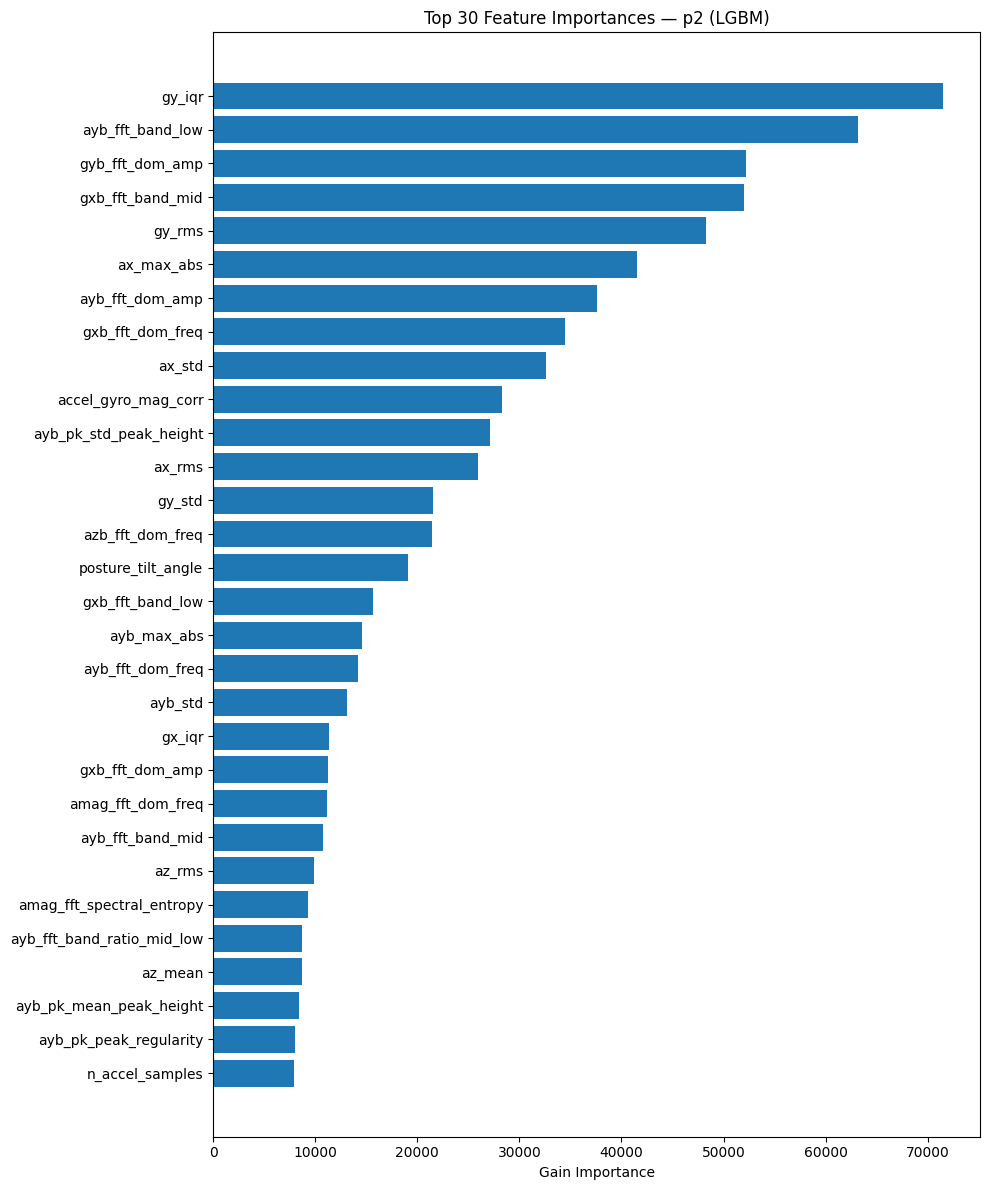

In [17]:
# ── Feature Importance ───────────────────────────────────────
import matplotlib.pyplot as plt

fi = pd.DataFrame({
    'feature':    feat_cols,
    'importance': lgbm_models[-1].feature_importance(importance_type='gain'),
}).sort_values('importance', ascending=False)

print("Top 30 features:")
print(fi.head(30).to_string(index=False))

plt.figure(figsize=(10, 12))
plt.barh(fi['feature'].head(30)[::-1], fi['importance'].head(30)[::-1])
plt.xlabel('Gain Importance')
plt.title('Top 30 Feature Importances — p2 (LGBM)')
plt.tight_layout()
plt.show()


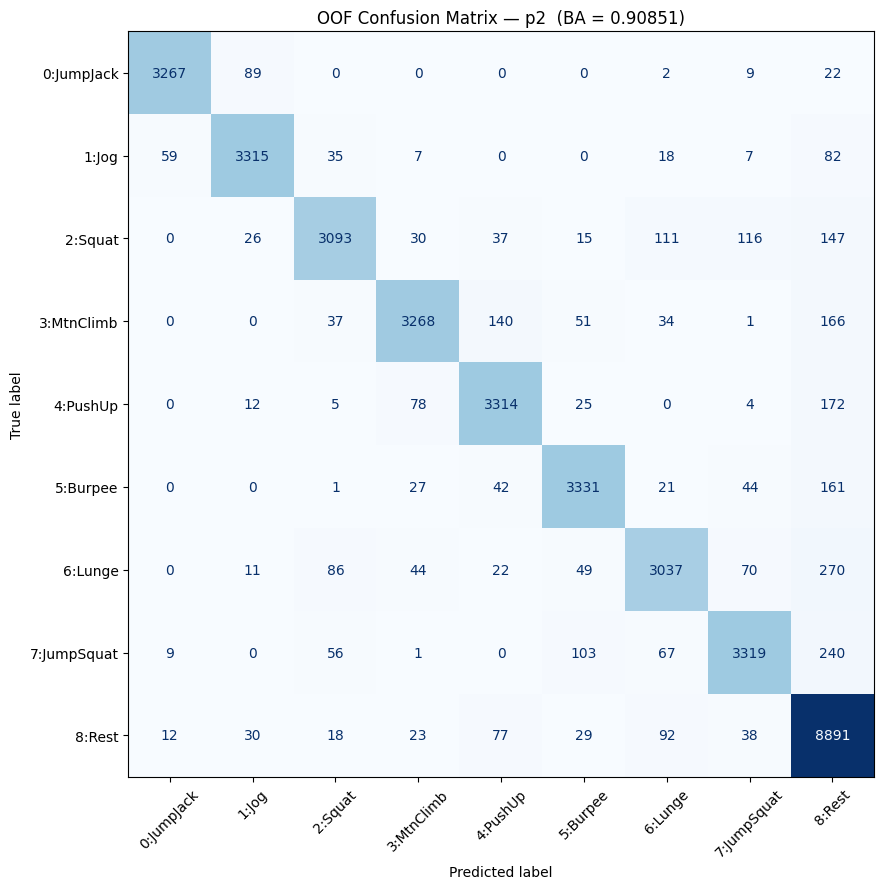


Per-class recall:
  0:JumpJack          : 0.964  ▲0.004 vs v1
  1:Jog               : 0.941  ▲0.052 vs v1
  2:Squat             : 0.865  ▲0.001 vs v1
  3:MtnClimb          : 0.884  ▲0.021 vs v1
  4:PushUp            : 0.918  ▲0.009 vs v1
  5:Burpee            : 0.918  ▲0.072 vs v1
  6:Lunge             : 0.846  ▼0.006 vs v1
  7:JumpSquat         : 0.875  ▲0.042 vs v1
  8:Rest              : 0.965  ▼0.001 vs v1


In [18]:
# ── OOF Confusion Matrix ─────────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

final_oof_preds = temporal_smooth(train_preds_raw, groups, window=5) \
    if oof_ba_smooth >= best_score else train_preds_raw

class_names = [
    '0:JumpJack','1:Jog','2:Squat','3:MtnClimb',
    '4:PushUp','5:Burpee','6:Lunge','7:JumpSquat','8:Rest'
]

cm = confusion_matrix(y_train, final_oof_preds)
fig, ax = plt.subplots(figsize=(11, 9))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)

final_ba = balanced_accuracy_score(y_train, final_oof_preds)
plt.title(f'OOF Confusion Matrix — p2  (BA = {final_ba:.5f})')
plt.tight_layout()
plt.show()

print("\nPer-class recall:")
for i, name in enumerate(class_names):
    r = cm[i,i] / cm[i].sum() if cm[i].sum() > 0 else 0
    delta = r - [0.960,0.889,0.864,0.863,0.909,0.846,0.852,0.833,0.966][i]
    arrow = '▲' if delta > 0 else '▼' if delta < 0 else '='
    print(f"  {name:20s}: {r:.3f}  {arrow}{abs(delta):.3f} vs v1")
